In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("../data/raw/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df["Gender"].unique() # valeurs différentes
df["Gender"].nunique() #nombre de valeurs différentes
df["Gender"].value_counts() #nombre de valeurs différentes
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [6]:
df.Teacher_Quality.value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [7]:
df.Teacher_Quality.value_counts()
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].value_counts().idxmax())

In [8]:
df.Teacher_Quality.value_counts().idxmax()

'Medium'

In [9]:
df.Distance_from_Home.value_counts()
df["Parental_Education_Level"]=df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].value_counts().idxmax())
df["Distance_from_Home"]=df["Distance_from_Home"].fillna(df["Distance_from_Home"].value_counts().idxmax())

### transformation en numérique

In [10]:
df_2 = pd.get_dummies(df, drop_first=True) # transforme tout les colonnes categorielle en numérique

In [11]:
df_distance_home= pd.get_dummies(df["Distance_from_Home"],prefix='dfh',dtype=int)

In [12]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [13]:
# X = df.drop(['Extracurricular_Activities',
#              'Sleep_Hours',
#              'Motivation_Level',
#             #  'Family_Income',
#              'Physical_Activity',
#              'Parental_Education_Level'], axis=1)

In [14]:
df_2

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,7,76,1,2,68,False,False,False,...,True,True,False,True,False,True,False,False,True,False
6603,23,76,8,81,3,2,69,False,False,False,...,False,True,False,True,False,True,False,False,True,False
6604,20,90,6,65,3,2,68,False,True,True,...,True,True,False,False,False,False,True,False,True,False
6605,10,86,6,91,2,3,68,False,False,False,...,True,False,False,True,False,True,False,False,False,False


In [15]:
X=df_2.drop("Exam_Score",axis=1)
y=df["Exam_Score"]

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import *

In [17]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=0)

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)
model.score(X,y)
y_pred=model.predict(x_test)

0.7270639623367308

In [ ]:
print("Accuracy test :", model.score(x_test, y_test))
print("Accuracy train :", model.score(x_train, y_train))

Accuracy test : 0.6685627187448367
Accuracy train : 0.7426089597695102


array([67.24459651, 66.35027131, 67.4648244 , ..., 66.81320139,
       66.9014675 , 63.37222864], shape=(1322,))

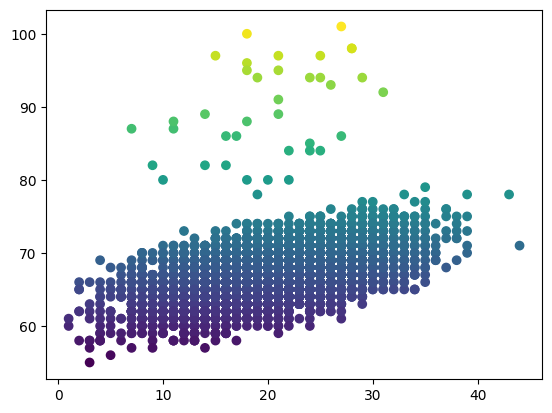

In [20]:
plt.scatter(x_train['Hours_Studied'],y_train,c=y_train)
# plt.plot(x_test["Hours_Studied"],y_pred)